# Sales Forecasting using Superstore Dataset

This project builds a time-series forecasting model to predict future sales using historical Superstore data.

## Problem Statement

The Objective of this project is to forecast future sales using historical Superstore data.

By analyzing past sales trends and seasonal patterns, we aim to build a model that can help business plan inventory, staffing, and financial decisions more effectively.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [13]:
import pandas as pd

df = pd.read_excel("Sample - Superstore.xlsx")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Dataset Overview

The Superstore dataset contains 9,994 records and 21 columns. It includes order details,customer information , product details,product categories, and sales information.

There are no missing values in the dataset.

The main objective is to forecast future sales using historical order data.

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [16]:
df['Order Date'].dtype

dtype('<M8[ns]')

In [17]:
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME')) ['Sales'].sum()
monthly_sales.head()

Order Date
2014-01-31    28953.706
2014-02-28    12743.108
2014-03-31    54801.906
2014-04-30    24710.016
2014-05-31    29639.834
Freq: ME, Name: Sales, dtype: float64

In [18]:
monthly_sales.head()

Order Date
2014-01-31    28953.706
2014-02-28    12743.108
2014-03-31    54801.906
2014-04-30    24710.016
2014-05-31    29639.834
Freq: ME, Name: Sales, dtype: float64

## Monthly Sales Aggregation 

The Sales data has been aggregated on a monthly basis using order date.

This helps identify trends and seasonality for forecasting.

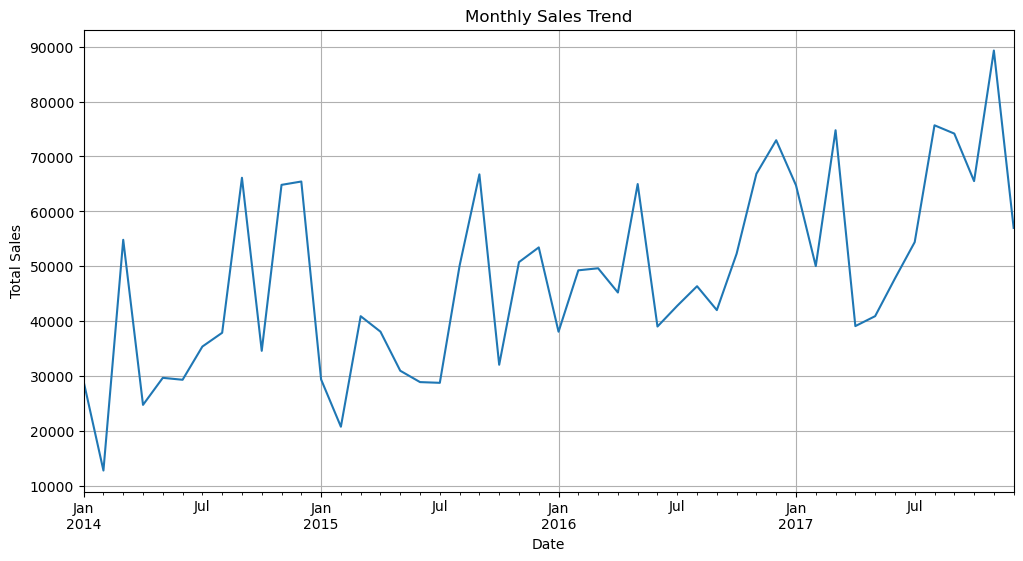

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

## Trend Observation

From the monthly sales trend, we can observe fluctuations in sales over time.

There are visible seasonal spikes and variations across different years.

This confirms that the data follows a time-series pattern suitable for forecasting.

In [20]:
train_size = int(len(monthly_sales) * 0.8)
train = monthly_sales[:train_size]
test = monthly_sales[train_size:]
print("Train size:",len(train))
print("Test size:",len(test))

Train size: 38
Test size: 10


## Train-Test Split

The dataset is split into training and testing sets using an 80-20 split.The training data is used to build the model, and the testing data is used to evaluate its performance.

In [21]:
from sklearn.linear_model import LinearRegression
import numpy as np

train_index = np.arange(len(train)).reshape(-1, 1)
test_index = np.arange(len(train),len(train) + len(test)).reshape(-1, 1)

model = LinearRegression()
model.fit(train_index, train)

predictions = model.predict(test_index)



## Model Training and Prediction

A Linear Regression model is trained on the training dataset.The model then predicts sales values for the test dataset.

In [22]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test,predictions)
print("Mean Absolute Error:",mae)

Mean Absolute Error: 13568.619801397308


The Mean Absolute Error(MAE) shows the average difference between actual and predicted sales values.A Lower MAE indicates better model performance.

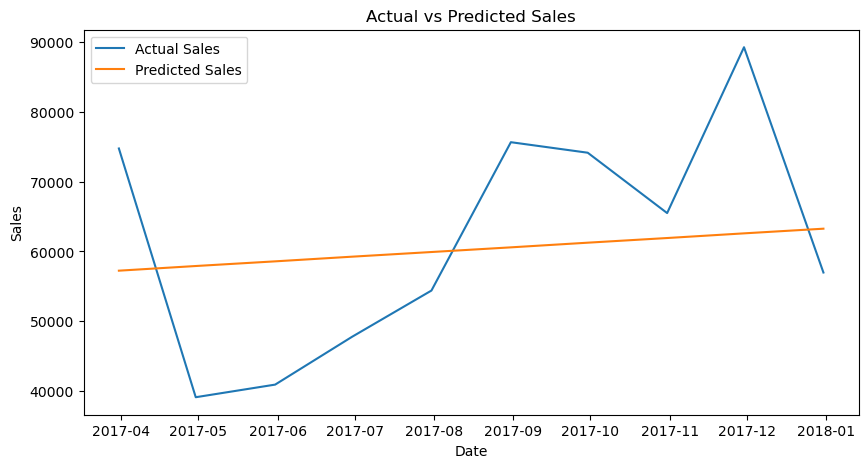

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(test.index, test, label="Actual Sales")
plt.plot(test.index, predictions, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

## Business Insights & Conclusion

The forecasting model predicts future monthly sales based on historical trends.

The Mean Absolute Error (MAE) indicates the average difference between actual and predicted sales values.

From the forecast, we observe an overall trend in sales movement.  
Businesses can use these predictions to:

- Plan inventory levels in advance  
- Optimize marketing campaigns  
- Manage cash flow and budgeting  
- Prepare for seasonal demand changes  

This model helps decision-makers take data-driven actions for better business planning.Overall, the model captures the general trend but does not fully capture seasonal variations.